In [ ]:
import marimo as mo

mo.md(
    """
    # Hello World: SingleOutputGP on a 1D Regression Problem

    A small end-to-end example using the live public wrapper API:
    `SingleOutputGP` plus an `RBF` kernel.
    """
)

# Hello World: SingleOutputGP on a 1D Regression Problem

A small end-to-end example using the live public wrapper API:
`SingleOutputGP` plus an `RBF` kernel.

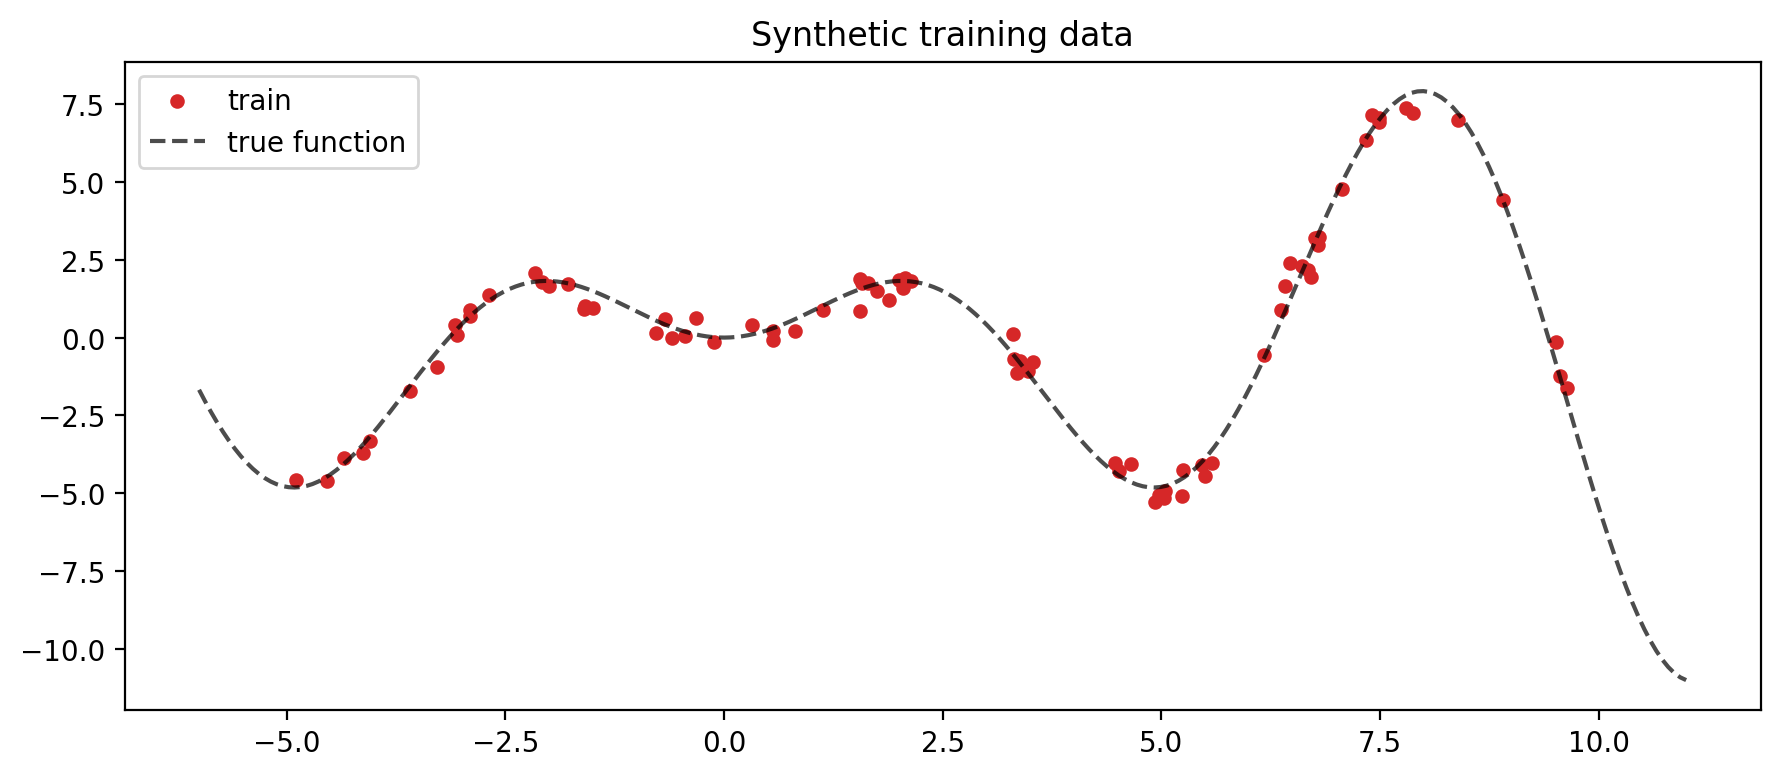

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(42)

def f(x):
    return x * np.sin(x)

X_train = np.sort(rng.uniform(-5, 10, 80)).astype(np.float32).reshape(-1, 1)
y_train = (f(X_train[:, 0]) + 0.4 * rng.standard_normal(80)).astype(np.float32)
X_test = np.linspace(-6, 11, 250, dtype=np.float32).reshape(-1, 1)
y_true = f(X_test[:, 0]).astype(np.float32)

fig, train_ax = plt.subplots(figsize=(9, 4))
train_ax.scatter(X_train[:, 0], y_train, s=18, color="tab:red", label="train")
train_ax.plot(X_test[:, 0], y_true, "k--", alpha=0.7, label="true function")
train_ax.set_title("Synthetic training data")
train_ax.legend()
fig.tight_layout()
plt.close(fig)
fig

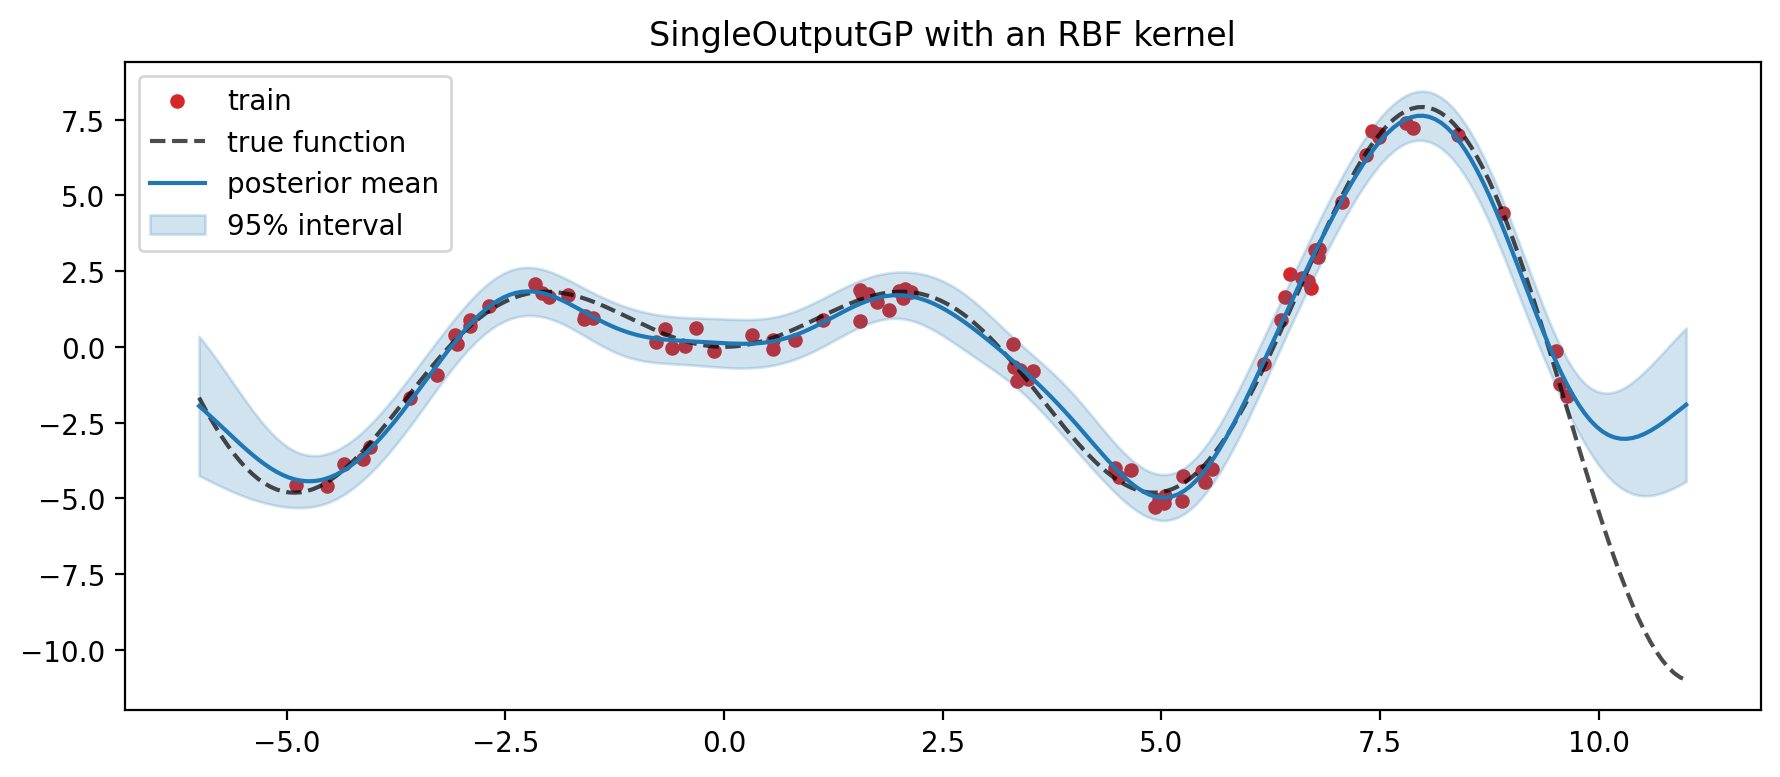

Quantity,Value
RMSE vs noiseless function,1.6659
Final NLL,1.0978
Learned lengthscale,0.9302
Learned outputscale,1.7590
Learned noise,0.1273

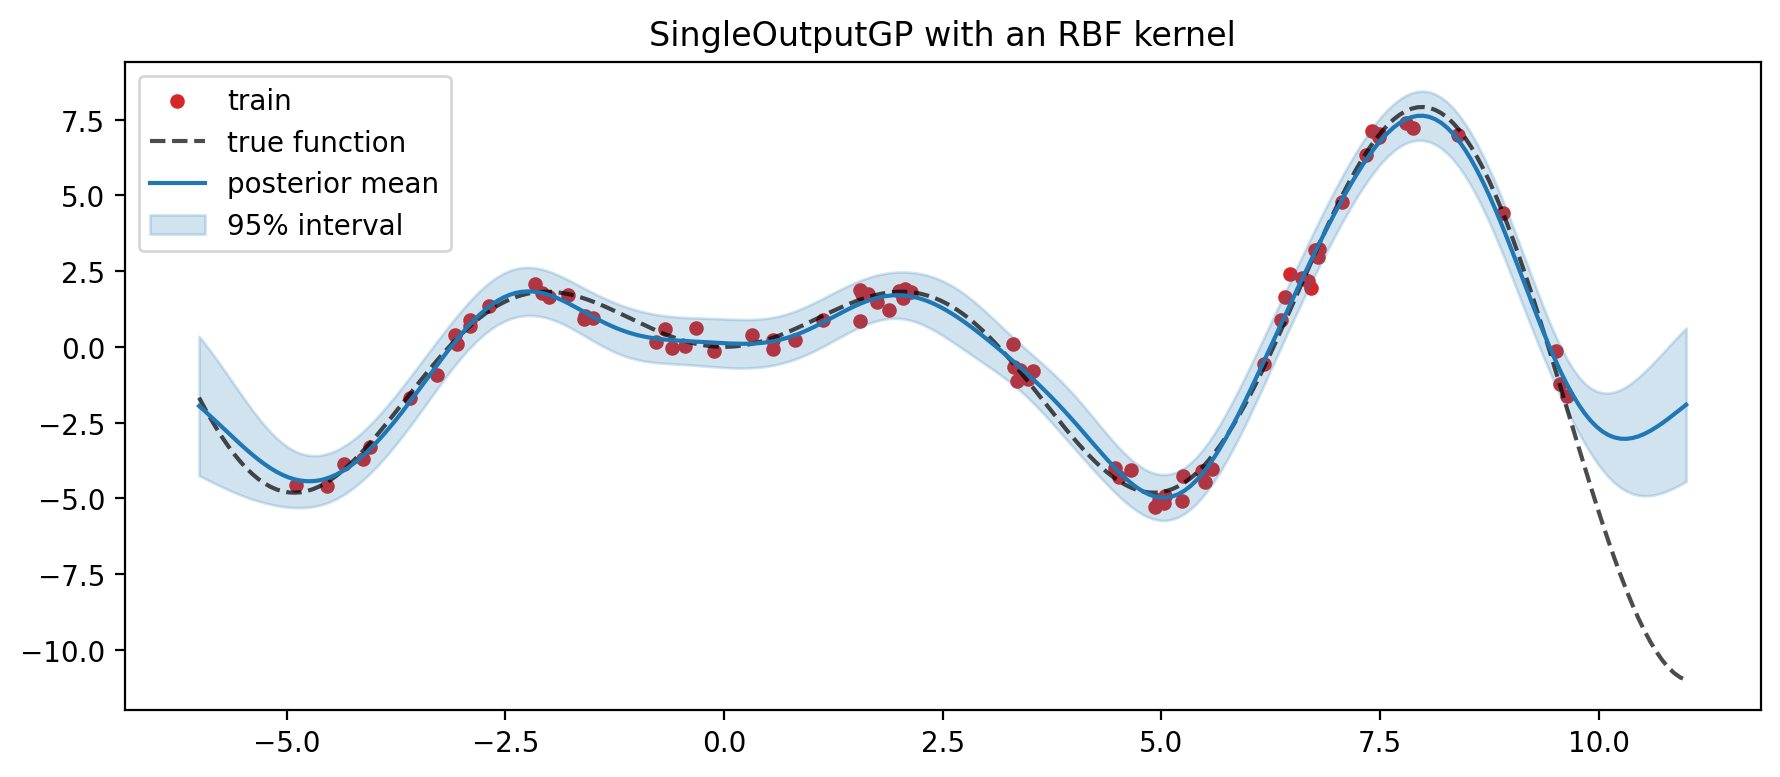

In [ ]:
from mojogp import SingleOutputGP, RBF

gp = SingleOutputGP(RBF(lengthscale=1.2, outputscale=1.0))
train_result = gp.fit(
    X_train,
    y_train,
    max_iterations=30,
    learning_rate=0.04,
    method="materialized",
    progress=True,
)

mean, std = gp.predict(X_test, return_std=True, progress=True)
rmse = float(np.sqrt(np.mean((mean - y_true) ** 2)))
params = gp.get_learned_params()

fig_pred, pred_ax = plt.subplots(figsize=(9, 4))
pred_ax.scatter(X_train[:, 0], y_train, s=18, color="tab:red", label="train")
pred_ax.plot(X_test[:, 0], y_true, "k--", alpha=0.7, label="true function")
pred_ax.plot(X_test[:, 0], mean, color="tab:blue", label="posterior mean")
pred_ax.fill_between(
    X_test[:, 0],
    mean - 2 * std,
    mean + 2 * std,
    alpha=0.2,
    color="tab:blue",
    label="95% interval",
)
pred_ax.set_title("SingleOutputGP with an RBF kernel")
pred_ax.legend()
fig_pred.tight_layout()
plt.close(fig_pred)
mo.vstack(
    [
        fig_pred,
        mo.md(
            f"""
            ## Fit Summary

            | Quantity | Value |
            |---|---:|
            | RMSE vs noiseless function | {rmse:.4f} |
            | Final NLL | {train_result.nll:.4f} |
            | Learned lengthscale | {params["rbf_lengthscale"]:.4f} |
            | Learned outputscale | {params["rbf_outputscale"]:.4f} |
            | Learned noise | {params["noise"]:.4f} |
            """
        ),
    ]
)